Epoch 1/100
391/391 - 4s - loss: 1.6294 - accuracy: 0.3987 - val_loss: 1.3643 - val_accuracy: 0.5062 - 4s/epoch - 9ms/step
Epoch 2/100
391/391 - 1s - loss: 1.2554 - accuracy: 0.5542 - val_loss: 1.0945 - val_accuracy: 0.6100 - 1s/epoch - 4ms/step
Epoch 3/100
391/391 - 1s - loss: 1.0738 - accuracy: 0.6216 - val_loss: 0.9445 - val_accuracy: 0.6611 - 1s/epoch - 4ms/step
Epoch 4/100
391/391 - 1s - loss: 0.9607 - accuracy: 0.6612 - val_loss: 0.9162 - val_accuracy: 0.6832 - 1s/epoch - 4ms/step
Epoch 5/100
391/391 - 1s - loss: 0.8909 - accuracy: 0.6879 - val_loss: 0.8615 - val_accuracy: 0.7017 - 1s/epoch - 4ms/step
Epoch 6/100
391/391 - 1s - loss: 0.8252 - accuracy: 0.7116 - val_loss: 0.7625 - val_accuracy: 0.7309 - 1s/epoch - 4ms/step
Epoch 7/100
391/391 - 1s - loss: 0.7796 - accuracy: 0.7264 - val_loss: 0.7517 - val_accuracy: 0.7394 - 1s/epoch - 4ms/step
Epoch 8/100
391/391 - 1s - loss: 0.7489 - accuracy: 0.7387 - val_loss: 0.7236 - val_accuracy: 0.7478 - 1s/epoch - 4ms/step
Epoch 9/100
391/

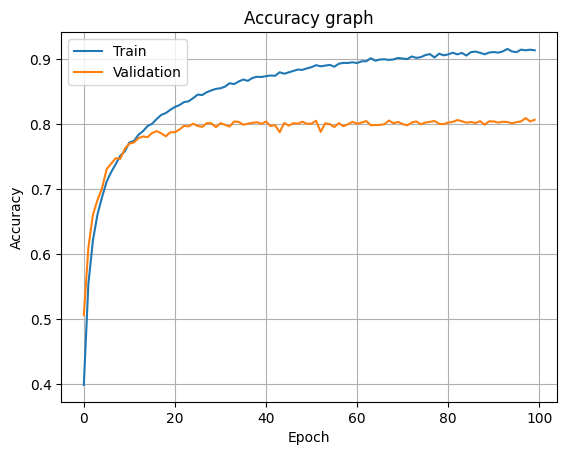

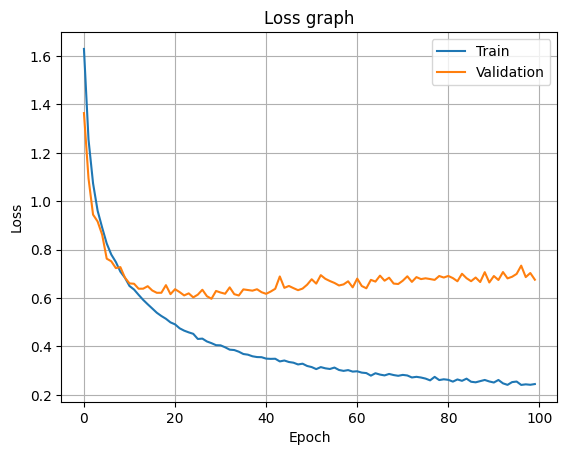

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.datasets as ds

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# [1] CIFAR-10 데이터 불러오기
# x_train: 훈련 이미지 (50000, 32, 32, 3)
# y_train: 훈련 라벨 (50000, 1)
(x_train, y_train), (x_test, y_test) = ds.cifar10.load_data()

# [2] 이미지 정규화: 0~255 → 0~1로 스케일링
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# [3] 레이블 One-hot 인코딩: 정수 → 벡터 (클래스 10개)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# [4] CNN 모델 정의
cnn = Sequential()

# Conv 블록 1: Conv → Conv → Pooling → Dropout
cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
# - 32개의 3x3 필터로 기본 에지/패턴 추출
cnn.add(Conv2D(32, (3, 3), activation='relu'))
# - 더 깊은 특징 추출
cnn.add(MaxPooling2D(pool_size=(2, 2)))
# - 공간 크기 절반으로 축소
cnn.add(Dropout(0.25))
# - 과적합 방지: 일부 노드 랜덤 off

# Conv 블록 2: Conv → Conv → Pooling → Dropout
cnn.add(Conv2D(64, (3, 3), activation='relu'))
# - 더 많은 필터로 더 복잡한 패턴 학습
cnn.add(Conv2D(64, (3, 3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Dropout(0.25))

# 완전 연결층 준비: Flatten
cnn.add(Flatten())
# - 3D feature map → 1D 벡터로 변환

# Fully Connected: Dense → Dropout
cnn.add(Dense(units=512, activation='relu'))
# - 512개의 뉴런으로 특징 조합
cnn.add(Dropout(0.5))
# - FC 계층에서 과적합 방지

# 출력층: 10개 클래스 → softmax로 확률 출력
cnn.add(Dense(units=10, activation='softmax'))

# [5] 모델 컴파일
# - 다중 클래스 분류: categorical_crossentropy
# - Adam optimizer: learning_rate=0.001
cnn.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# [6] 모델 학습
# - batch_size=128, epochs=100
# - 검증 데이터: x_test, y_test
hist = cnn.fit(
    x_train, y_train,
    batch_size=128,
    epochs=100,
    validation_data=(x_test, y_test),
    verbose=2
)

# [7] 테스트 정확도 출력
res = cnn.evaluate(x_test, y_test, verbose=0)
print('정확률 =', res[1] * 100)

# [8] 정확도 그래프 출력
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Accuracy graph')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

# [9] 손실 그래프 출력
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Loss graph')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

